<a href="https://colab.research.google.com/github/AchuriNeelima/SugarSense-Diabetes-Risk-Prediction/blob/main/SugarSense_Diabetes_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SugarSense: Early Diabetes Risk Screening

## Phase 1 – Data Audit

This project uses supervised machine learning to predict whether a patient is likely to have diabetes based on eight clinical measurements.

The target variable is `Outcome`, where:
- 0 = Not diabetic
- 1 = Diabetic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving diabetes_screening_data.xlsx.xlsx to diabetes_screening_data.xlsx.xlsx


In [5]:
import pandas as pd

df = pd.read_excel("diabetes_screening_data.xlsx")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (768, 9)


In [7]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [19]:
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [20]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    print(f"{col}: {(df[col] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [16]:
zero_percentages = {}

for col in zero_columns:
    percentage = (df[col] == 0).mean() * 100
    zero_percentages[col] = percentage
    print(f"{col}: {percentage:.2f}%")

Glucose: 0.65%
BloodPressure: 4.56%
SkinThickness: 29.56%
Insulin: 48.70%
BMI: 1.43%


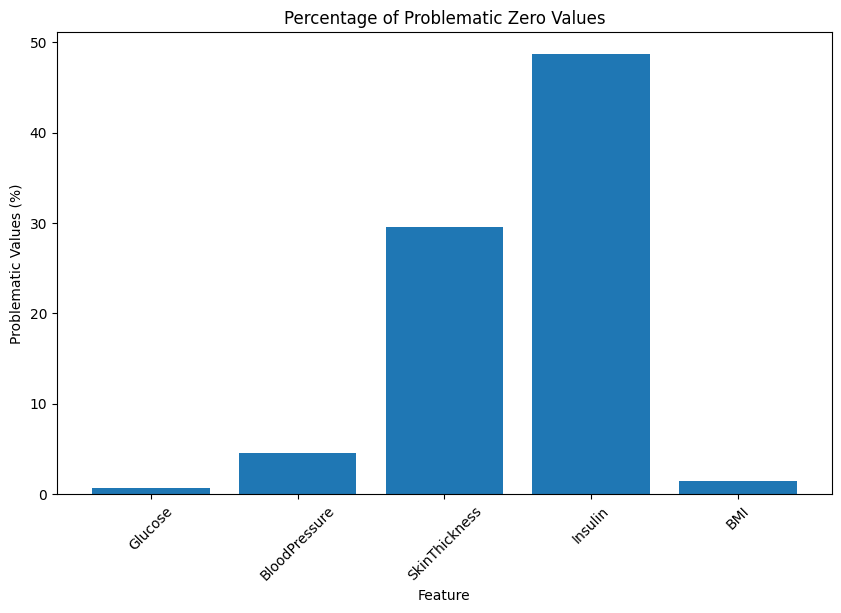

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    zero_percentages.keys(),
    zero_percentages.values()
)

plt.title("Percentage of Problematic Zero Values")
plt.xlabel("Feature")
plt.ylabel("Problematic Values (%)")

plt.xticks(rotation=45)

plt.show()

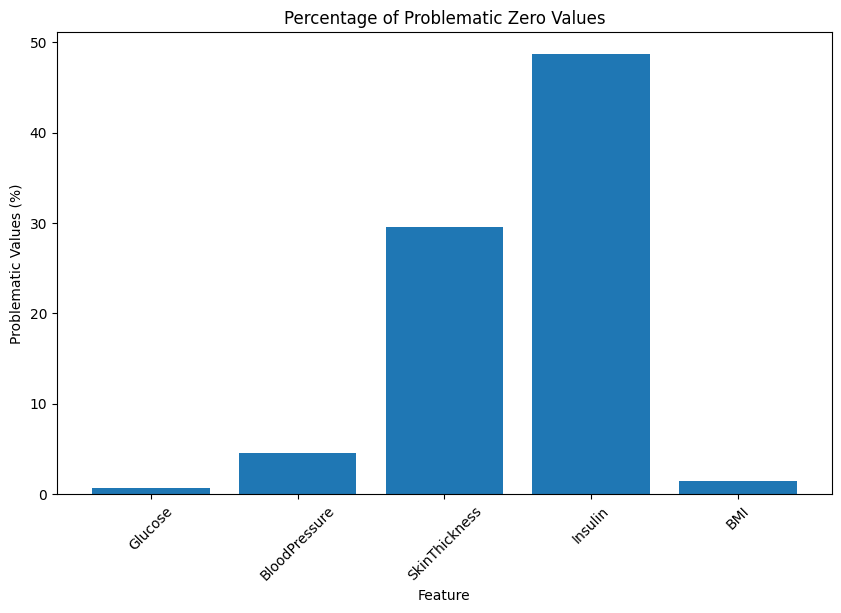

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    zero_percentages.keys(),
    zero_percentages.values()
)

plt.title("Percentage of Problematic Zero Values")
plt.xlabel("Feature")
plt.ylabel("Problematic Values (%)")

plt.xticks(rotation=45)

plt.show()

### Phase 1 – Data Audit

The dataset contains 768 patient records and 9 columns, consisting of 8 clinical input features and one target variable, `Outcome`. There are no duplicate rows and no explicit missing values detected using `isnull()`. The target variable contains 500 non-diabetic patients (65.10%) and 268 diabetic patients (34.90%), indicating moderate class imbalance.

However, the dataset contains hidden missing values represented by zero. Zero values were found in Glucose, BloodPressure, SkinThickness, Insulin, and BMI. These zero values are considered problematic because they do not represent realistic measurements for these clinical variables. Therefore, they will be treated as missing values and handled later using imputation inside the machine-learning pipelines to avoid data leakage.


## Phase 2 – Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of the clinical features and identify patterns associated with diabetes. The distributions of the features are compared between diabetic and non-diabetic patients. A correlation heatmap is also used to examine relationships between numerical variables.


In [21]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

print(features)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


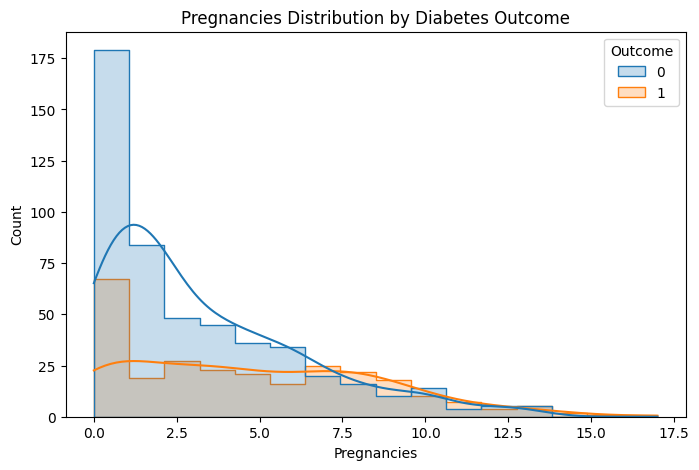

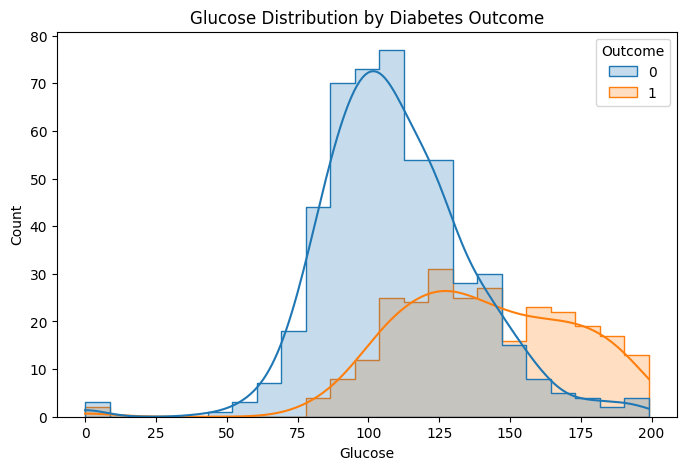

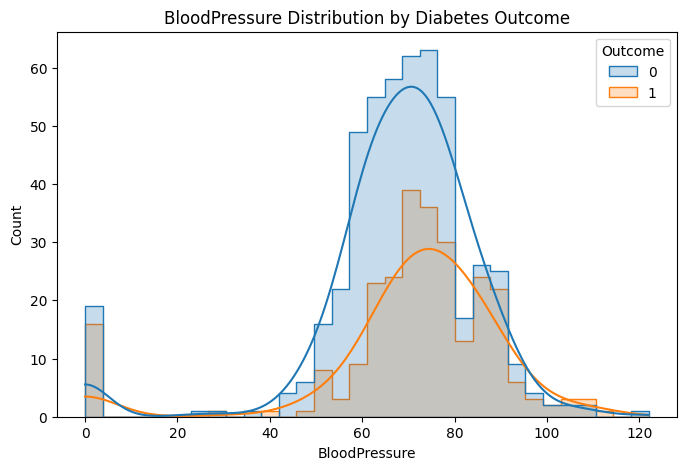

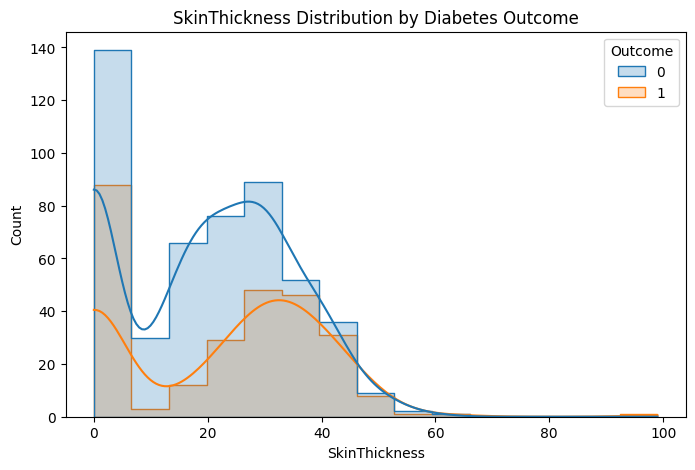

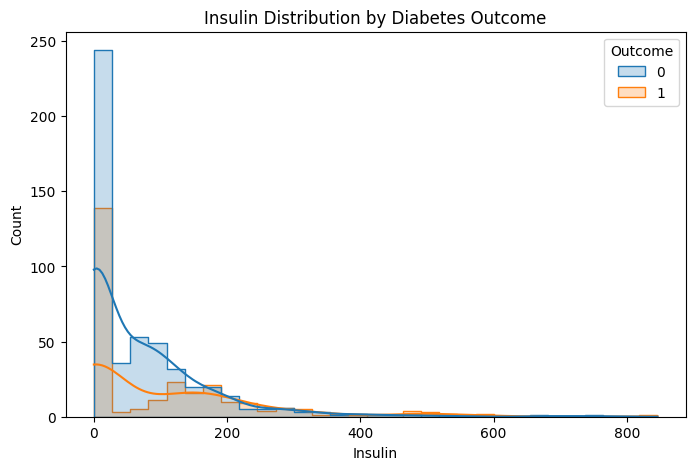

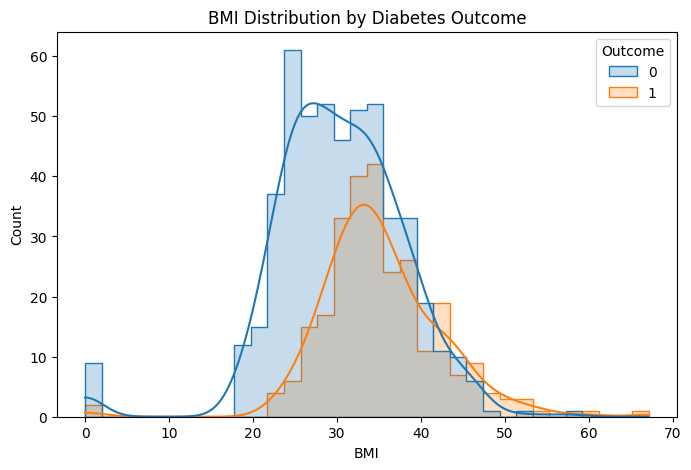

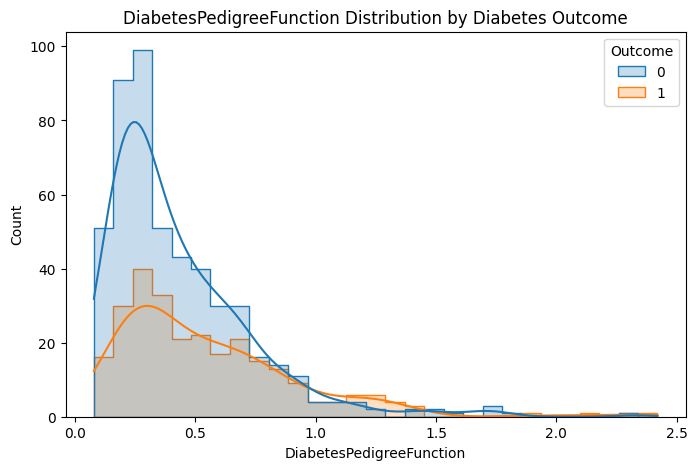

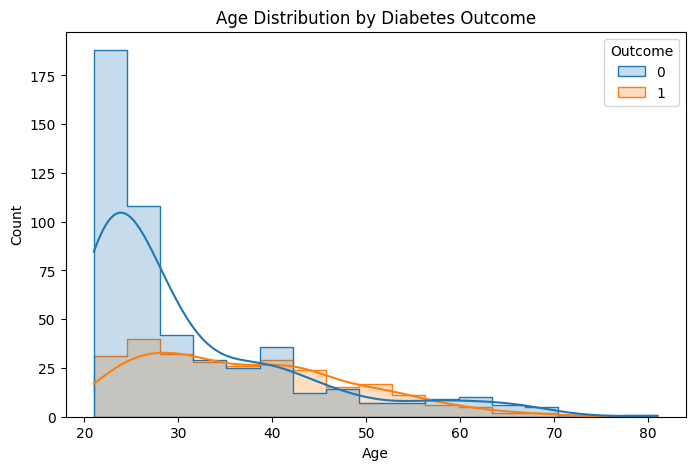

In [22]:
for feature in features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Outcome",
        kde=True,
        element="step"
    )

    plt.title(f"{feature} Distribution by Diabetes Outcome")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.show()

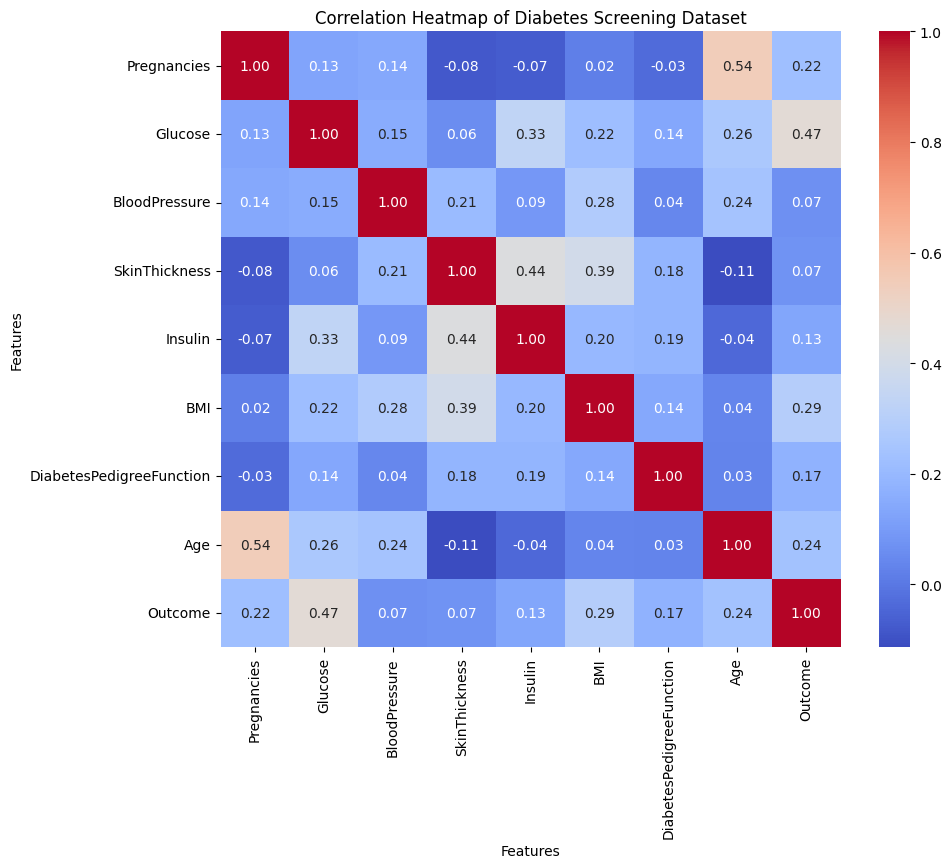

In [23]:
plt.figure(figsize=(10, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Diabetes Screening Dataset")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [24]:
outcome_correlation = df.corr(numeric_only=True)["Outcome"].sort_values(
    ascending=False
)

print(outcome_correlation)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


## Phase 3 – Feature Engineering

Feature engineering is used to create additional features from the existing clinical measurements. The new features are based only on information available for each individual patient and do not use statistics calculated from the complete dataset. These features are intended to represent simple risk-related patterns that may help the machine-learning models.


In [25]:
# 1. Obesity flag
df["ObesityFlag"] = (df["BMI"] >= 30).astype(int)

# 2. Age risk flag
df["AgeRiskFlag"] = (df["Age"] >= 40).astype(int)

# 3. Glucose-BMI interaction
df["Glucose_BMI"] = df["Glucose"] * df["BMI"]

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,ObesityFlag,AgeRiskFlag,Glucose_BMI
0,6,148,72,35,0,33.6,0.627,50,1,1,1,4972.8
1,1,85,66,29,0,26.6,0.351,31,0,0,0,2261.0
2,8,183,64,0,0,23.3,0.672,32,1,0,0,4263.9
3,1,89,66,23,94,28.1,0.167,21,0,0,0,2500.9
4,0,137,40,35,168,43.1,2.288,33,1,1,0,5904.7


In [28]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'ObesityFlag', 'AgeRiskFlag', 'Glucose_BMI']


In [29]:
print(df[["BMI", "ObesityFlag", "Age", "AgeRiskFlag", "Glucose", "Glucose_BMI"]].head(10))

    BMI  ObesityFlag  Age  AgeRiskFlag  Glucose  Glucose_BMI
0  33.6            1   50            1      148       4972.8
1  26.6            0   31            0       85       2261.0
2  23.3            0   32            0      183       4263.9
3  28.1            0   21            0       89       2500.9
4  43.1            1   33            0      137       5904.7
5  25.6            0   30            0      116       2969.6
6  31.0            1   26            0       78       2418.0
7  35.3            1   29            0      115       4059.5
8  30.5            1   53            1      197       6008.5
9   0.0            0   54            1      125          0.0


In [30]:
import numpy as np

# Create a copy for machine learning
df_model = df.copy()

# Columns where zero represents a missing/problematic value
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace 0 with NaN
df_model[zero_as_missing] = df_model[zero_as_missing].replace(0, np.nan)

# Check missing values
print(df_model.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
ObesityFlag                   0
AgeRiskFlag                   0
Glucose_BMI                   0
dtype: int64


In [31]:
# Separate input features and target
X = df_model.drop(columns=["Outcome"])
y = df_model["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 11)
y shape: (768,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (614, 11)
Testing data: (154, 11)

Training target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [35]:
# Calculate class imbalance ratio for XGBoost
class_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# 1. Logistic Regression
logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

# 2. K-Nearest Neighbors
knn_model = KNeighborsClassifier(
    weights="distance"
)

# 3. Decision Tree
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# 4. Random Forest
random_forest_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# 5. XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=class_ratio,
    random_state=42,
    eval_metric="logloss"
)

# 6. Support Vector Machine
svm_model = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

print("All six models created successfully.")

All six models created successfully.


In [37]:
class_weight="balanced"

In [38]:
scale_pos_weight=class_ratio

In [39]:
weights="distance"

In [40]:
scaled_models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "SVM": svm_model
}

scaled_pipelines = {}

for name, model in scaled_models.items():
    scaled_pipelines[name] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

In [41]:
tree_models = {
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

tree_pipelines = {}

for name, model in tree_models.items():
    tree_pipelines[name] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

In [42]:
pipelines = {}

pipelines.update(scaled_pipelines)
pipelines.update(tree_pipelines)

print("Number of pipelines:", len(pipelines))
print("\nModels:")
for name in pipelines:
    print("-", name)

Number of pipelines: 6

Models:
- Logistic Regression
- KNN
- SVM
- Decision Tree
- Random Forest
- XGBoost


In [43]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created successfully.")

5-Fold Stratified Cross-Validation created successfully.


In [44]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []

for name, pipeline in pipelines.items():

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "Model": name,

        "Accuracy Mean": cv_results["test_accuracy"].mean(),
        "Accuracy Std": cv_results["test_accuracy"].std(),

        "Precision Mean": cv_results["test_precision"].mean(),
        "Precision Std": cv_results["test_precision"].std(),

        "Recall Mean": cv_results["test_recall"].mean(),
        "Recall Std": cv_results["test_recall"].std(),

        "F1 Mean": cv_results["test_f1"].mean(),
        "F1 Std": cv_results["test_f1"].std(),

        "ROC-AUC Mean": cv_results["test_roc_auc"].mean(),
        "ROC-AUC Std": cv_results["test_roc_auc"].std(),

        "Train ROC-AUC": cv_results["train_roc_auc"].mean(),

        "Overfit Gap": (
            cv_results["train_roc_auc"].mean()
            - cv_results["test_roc_auc"].mean()
        )
    })

results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by="ROC-AUC Mean",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std,Train ROC-AUC,Overfit Gap
0,Logistic Regression,0.776876,0.015018,0.660361,0.021204,0.743079,0.041037,0.698580,0.022641,0.842323,0.016554,0.856193,0.013870
1,SVM,0.773557,0.032735,0.656385,0.064372,0.766334,0.053078,0.703271,0.028760,0.839208,0.022897,0.913139,0.073931
2,Random Forest,0.763774,0.033884,0.694929,0.074042,0.588704,0.048437,0.634957,0.046466,0.821479,0.036926,1.000000,0.178521
3,KNN,0.750860,0.022893,0.674007,0.059322,0.575415,0.080104,0.614792,0.038102,0.809576,0.035539,1.000000,0.190424
4,XGBoost,0.724683,0.025763,0.604326,0.041803,0.616611,0.042525,0.609446,0.034974,0.777612,0.033198,1.000000,0.222388
5,Decision Tree,0.680754,0.038151,0.543308,0.054873,0.555592,0.061195,0.547831,0.051221,0.651546,0.038773,1.000000,0.348454


In [45]:
# Select the top 3 models based on mean ROC-AUC
top_3_models = results_df.head(3)["Model"].tolist()

print("Top 3 models selected for tuning:")
for model in top_3_models:
    print("-", model)

Top 3 models selected for tuning:
- Logistic Regression
- SVM
- Random Forest


In [46]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform

param_distributions = {

    "Logistic Regression": {
        "model__C": loguniform(0.001, 100),
        "model__solver": ["liblinear", "lbfgs"]
    },

    "KNN": {
        "model__n_neighbors": randint(3, 31),
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "SVM": {
        "model__C": loguniform(0.01, 100),
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf", "linear"]
    },

    "Decision Tree": {
        "model__max_depth": randint(2, 15),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": randint(2, 15),
        "model__min_samples_leaf": randint(1, 8),
        "model__max_features": ["sqrt", "log2"]
    },

    "XGBoost": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(2, 8),
        "model__learning_rate": uniform(0.01, 0.29),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4)
    }
}

print("Hyperparameter search spaces created.")

Hyperparameter search spaces created.


In [47]:
tuned_models = {}
tuning_results = []

for name in top_3_models:

    print(f"\nTuning {name}...")

    search = RandomizedSearchCV(
        estimator=pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best ROC-AUC": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print("Best ROC-AUC:", search.best_score_)
    print("Best Parameters:", search.best_params_)


Tuning Logistic Regression...
Best ROC-AUC: 0.842673034330011
Best Parameters: {'model__C': np.float64(3.4702669886504163), 'model__solver': 'lbfgs'}

Tuning SVM...
Best ROC-AUC: 0.8447439091915836
Best Parameters: {'model__C': np.float64(5.456725485601478), 'model__gamma': 'scale', 'model__kernel': 'linear'}

Tuning Random Forest...
Best ROC-AUC: 0.8369172203765227
Best Parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 191}


In [48]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df

,Model,Best ROC-AUC,Best Parameters
0,Logistic Regression,0.842673,"{'model__C': 3.4702669886504163, 'model__solve..."
1,SVM,0.844744,"{'model__C': 5.456725485601478, 'model__gamma'..."
2,Random Forest,0.836917,"{'model__max_depth': 5, 'model__max_features':..."


In [49]:
tuning_df

,Model,Best ROC-AUC,Best Parameters
0,Logistic Regression,0.842673,"{'model__C': 3.4702669886504163, 'model__solve..."
1,SVM,0.844744,"{'model__C': 5.456725485601478, 'model__gamma'..."
2,Random Forest,0.836917,"{'model__max_depth': 5, 'model__max_features':..."


In [50]:
best_model_name = tuning_df.loc[
    tuning_df["Best ROC-AUC"].idxmax(),
    "Model"
]

best_model = tuned_models[best_model_name]

print("Best tuned model:", best_model_name)
print("Best CV ROC-AUC:", tuning_df["Best ROC-AUC"].max())

Best tuned model: SVM
Best CV ROC-AUC: 0.8447439091915836


In [51]:
best_model.fit(X_train, y_train)

print("Best model trained successfully.")

Best model trained successfully.


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions on untouched test data
y_test_pred = best_model.predict(X_test)

# Probability of the positive class
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# Final test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Final Test Results")
print("------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")

Final Test Results
------------------
Accuracy : 0.7403
Precision: 0.6061
Recall   : 0.7407
F1 Score : 0.6667
ROC-AUC  : 0.8067


Confusion Matrix:
[[74 26]
 [14 40]]


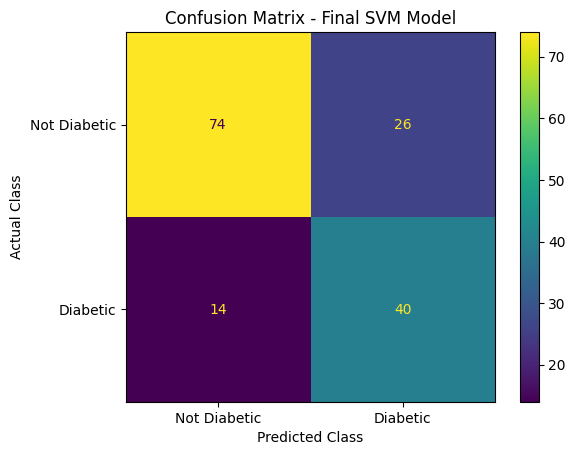

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Confusion Matrix - Final SVM Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

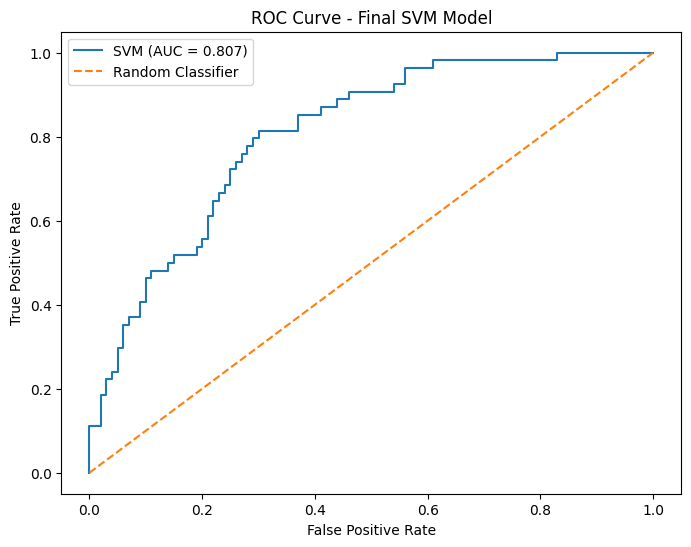

In [54]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Final SVM Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

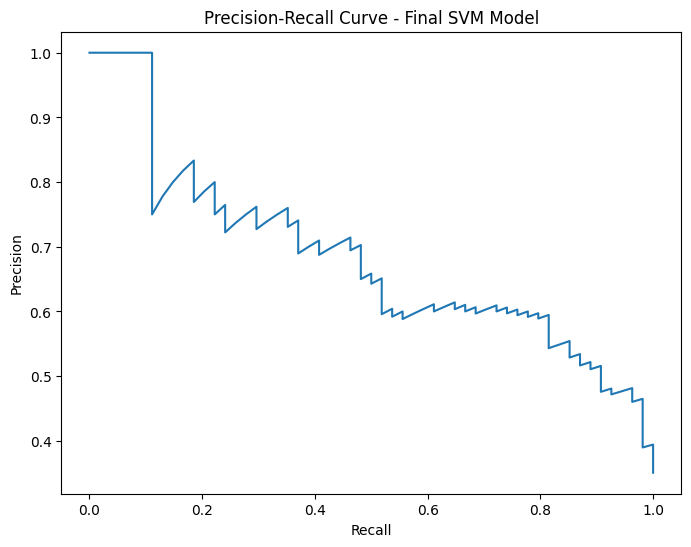

In [55]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.title("Precision-Recall Curve - Final SVM Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [56]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold probability predictions using training data
oof_prob = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold predictions generated.")
print("Number of predictions:", len(oof_prob))

Out-of-fold predictions generated.
Number of predictions: 614


In [57]:
from sklearn.metrics import precision_score, recall_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    oof_pred = (oof_prob >= threshold).astype(int)

    precision = precision_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall
    })

threshold_df = pd.DataFrame(threshold_results)

# Keep only thresholds achieving at least 85% recall
eligible_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.85
]

# Select the threshold with the highest precision
best_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["Precision"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold:", best_threshold)
print("Training OOF Precision:", best_threshold_row["Precision"])
print("Training OOF Recall:", best_threshold_row["Recall"])

Best threshold: 0.22999999999999995
Training OOF Precision: 0.5314285714285715
Training OOF Recall: 0.8691588785046729


In [58]:
# Default threshold = 0.50
default_test_pred = (y_test_prob >= 0.50).astype(int)

# Tuned threshold
tuned_test_pred = (y_test_prob >= best_threshold).astype(int)

print("DEFAULT THRESHOLD (0.50)")
print("-----------------------")
print("Precision:", precision_score(y_test, default_test_pred))
print("Recall   :", recall_score(y_test, default_test_pred))
print("F1 Score :", f1_score(y_test, default_test_pred))

print("\nTUNED THRESHOLD")
print("----------------")
print("Threshold:", best_threshold)
print("Precision:", precision_score(y_test, tuned_test_pred))
print("Recall   :", recall_score(y_test, tuned_test_pred))
print("F1 Score :", f1_score(y_test, tuned_test_pred))

DEFAULT THRESHOLD (0.50)
-----------------------
Precision: 0.6363636363636364
Recall   : 0.5185185185185185
F1 Score : 0.5714285714285714

TUNED THRESHOLD
----------------
Threshold: 0.22999999999999995
Precision: 0.5348837209302325
Recall   : 0.8518518518518519
F1 Score : 0.6571428571428571


In [59]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
).reset_index(drop=True)

importance_df

,Feature,Importance Mean,Importance Std
0,Glucose,0.172333,0.033825
1,Pregnancies,0.021778,0.009052
2,BMI,0.017500,0.012987
3,DiabetesPedigreeFunction,0.016241,0.005961
4,ObesityFlag,0.011278,0.009574
5,Glucose_BMI,0.006074,0.003505
6,SkinThickness,0.000944,0.002707
7,Age,0.000722,0.001794
8,AgeRiskFlag,0.000463,0.004594
9,Insulin,-0.000037,0.000789


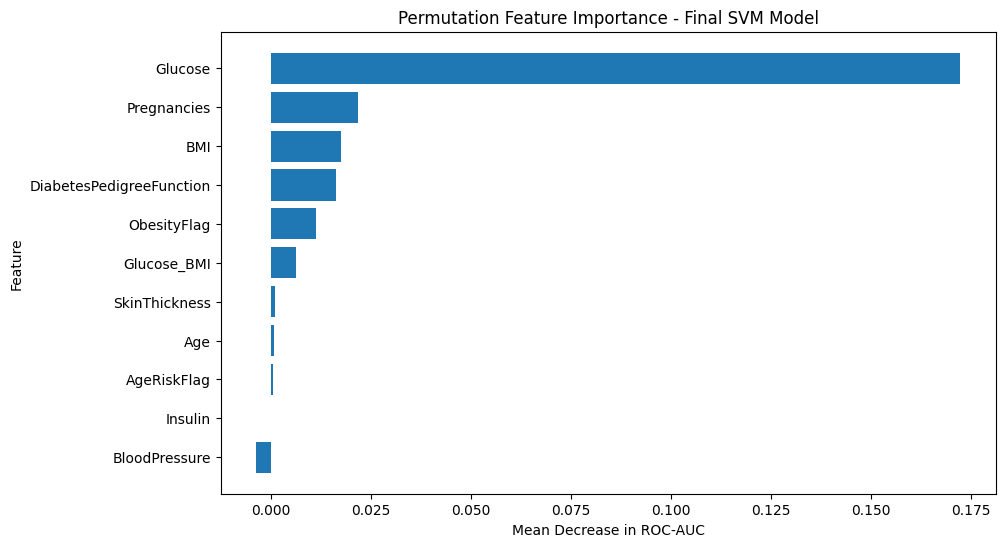

In [60]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance Mean"]
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Final SVM Model")

plt.gca().invert_yaxis()

plt.show()

### Feature Importance Observations

The permutation feature importance results show that **Glucose** is the most influential feature in the final SVM model. **Pregnancies**, **BMI**, and **DiabetesPedigreeFunction** also contribute to the model's predictions. The engineered features **ObesityFlag** and **Glucose_BMI** provide additional information, although their contribution is smaller than the original Glucose feature. **SkinThickness**, **Age**, and **AgeRiskFlag** have very small importance values, while **Insulin** and **BloodPressure** show near-zero or slightly negative importance in this permutation test. Overall, Glucose appears to be the strongest predictor used by the final model.